In [1]:
!pip -q install pyvista trimesh scikit-learn scipy scikit-image numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.3/204.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.9/145.9 MB 5.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pyvista as pv
import trimesh

from scipy.spatial import cKDTree
from scipy.ndimage import gaussian_filter1d, gaussian_filter
from scipy.signal import savgol_filter

from sklearn.decomposition import PCA
from skimage.measure import EllipseModel, ransac

In [74]:
VTK_PATH = "prestress2800000.vtk"
STL_PATH = "drillhead2800000.stl"
OUT_STL  = "borehole_final_smooth.stl"

USE_MIRROR_XZ = True

DIST_THRESH = 0.12

STEP_ALONG = 0.01

SLAB_HALF_THICK = 0.02

MIN_SLICE_PTS = 20

BALL_R = 0.06

# Gradient candidate selection
GRAD_GRID_RES   = 60
GRAD_THRESH_PCT = 70

# Reject slices where the candidate cloud is too elongated to fit a circle
# aspect ratio = sqrt(eigenvalue_max / eigenvalue_min) of candidate covariance
MAX_ASPECT_RATIO = 1.4

# Circle RANSAC params (geometric distance units)
RANSAC_TRIALS   = 160
CIRCLE_TOL      = 0.008
MIN_INLIER_FRAC = 0.50

RING_N = 48

In [88]:
def mirror_about_xz(points):
    p = points.copy()
    p[:, 1] *= -1.0
    return p

def normalize(v, eps=1e-12):
    n = np.linalg.norm(v)
    return v / n if n >= eps else v * 0.0

def get_plane_basis(n):
    n = normalize(n)
    v = np.array([1.0, 0.0, 0.0])
    if abs(np.dot(v, n)) > 0.9:
        v = np.array([0.0, 1.0, 0.0])
    e1 = normalize(np.cross(n, v))
    e2 = normalize(np.cross(n, e1))
    return e1, e2

def gradient_boundary_pts(pts2d, grid_res=60, grad_thresh_pct=60):
    """Select points near the void-soil density boundary via 2D gradient magnitude."""
    if pts2d.shape[0] < 20:
        return np.ones(pts2d.shape[0], dtype=bool)
    x, y = pts2d[:, 0], pts2d[:, 1]
    pad = 0.1 * max(x.max() - x.min(), y.max() - y.min(), 1e-6)
    H, xedges, yedges = np.histogram2d(
        x, y, bins=grid_res,
        range=[[x.min() - pad, x.max() + pad], [y.min() - pad, y.max() + pad]]
    )
    H_smooth = gaussian_filter(H, sigma=1.5)
    gx, gy = np.gradient(H_smooth)
    grad_mag = np.sqrt(gx**2 + gy**2)
    thresh = np.percentile(grad_mag, grad_thresh_pct)
    boundary_grid = grad_mag > thresh
    xi = np.clip(np.digitize(x, xedges[:-1]) - 1, 0, grid_res - 1)
    yi = np.clip(np.digitize(y, yedges[:-1]) - 1, 0, grid_res - 1)
    return boundary_grid[xi, yi]

def fit_circle_3pts(p1, p2, p3, eps=1e-12):
    (x1,y1),(x2,y2),(x3,y3) = p1, p2, p3
    A = np.array([[x2-x1, y2-y1], [x3-x1, y3-y1]], dtype=float)
    B = np.array([
        0.5*((x2**2-x1**2)+(y2**2-y1**2)),
        0.5*((x3**2-x1**2)+(y3**2-y1**2))
    ], dtype=float)
    if abs(np.linalg.det(A)) < eps:
        return None
    cx, cy = np.linalg.solve(A, B)
    r = np.sqrt((cx-x1)**2 + (cy-y1)**2)
    return (cx, cy, r) if np.isfinite(r) and r > 0 else None

def ransac_circle(pts2d, n_trials=160, tol=0.008, min_inlier_frac=0.12, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    N = pts2d.shape[0]
    if N < 10:
        return None
    best_inliers, best_model, best_mask = 0, None, None
    for _ in range(n_trials):
        idx = rng.choice(N, size=3, replace=False)
        model = fit_circle_3pts(pts2d[idx[0]], pts2d[idx[1]], pts2d[idx[2]])
        if model is None:
            continue
        cx, cy, r = model
        resid = np.abs(np.sqrt((pts2d[:,0]-cx)**2 + (pts2d[:,1]-cy)**2) - r)
        mask = resid < tol
        cnt  = mask.sum()
        if cnt > best_inliers:
            best_inliers, best_model, best_mask = cnt, model, mask
    if best_model is None or best_inliers / N < min_inlier_frac:
        return None
    return (*best_model, best_mask)

def circle_ring_3d(c, e1, e2, cx, cy, r, n=48):
    t = np.linspace(0, 2*np.pi, n, endpoint=False)
    lx = cx + r * np.cos(t)
    ly = cy + r * np.sin(t)
    return c + lx[:, None]*e1 + ly[:, None]*e2

def loft_rings_to_mesh(rings3d):
    N = rings3d[0].shape[0]
    verts = np.vstack(rings3d)
    faces = []
    def idx(i, j):
        return i * N + (j % N)
    for i in range(len(rings3d) - 1):
        for j in range(N):
            a0, a1 = idx(i, j), idx(i, j+1)
            b0, b1 = idx(i+1, j), idx(i+1, j+1)
            faces.append([a0, b0, a1])
            faces.append([a1, b0, b1])
    return trimesh.Trimesh(np.array(verts), np.array(faces, dtype=np.int64), process=False)

In [89]:
soil = pv.read(VTK_PATH)
points = np.asarray(soil.points)

tool = trimesh.load_mesh(STL_PATH)
tool_pts = np.asarray(tool.vertices)

print("Soil points:", points.shape)
print("Tool vertices:", tool_pts.shape)

if USE_MIRROR_XZ:
    points = np.vstack([points, mirror_about_xz(points)])
    print("After mirroring:", points.shape)

Soil points: (696791, 3)
Tool vertices: (3658, 3)
After mirroring: (1393582, 3)


In [90]:
tree = cKDTree(tool_pts)
dists, _ = tree.query(points, k=1)

hole_pts = points[dists < DIST_THRESH]

MAX_PTS = 250_000   # safe for laptop

if hole_pts.shape[0] > MAX_PTS:
    idx = np.random.choice(hole_pts.shape[0], MAX_PTS, replace=False)
    hole_pts = hole_pts[idx]

print("Hole candidate points:", hole_pts.shape)

if hole_pts.shape[0] < 1000:
    print("\nWARNING: Very few near-tool points. Try increasing DIST_THRESH.\n")

print("Distance stats:")
print(" min:", dists.min())
print(" median:", np.median(dists))
print(" mean:", dists.mean())
print(" max:", dists.max())

Hole candidate points: (250000, 3)
Distance stats:
 min: 0.0003335340419873248
 median: 0.08366718310710813
 mean: 0.17280180280634566
 max: 0.6136396909241136


In [91]:
pca = PCA(3)
pca.fit(hole_pts)

main_dir = normalize(pca.components_[0])
center0 = hole_pts.mean(axis=0)

proj = (hole_pts - center0) @ main_dir

s_min, s_max = proj.min(), proj.max()
stations = np.arange(s_min, s_max, STEP_ALONG)

print("Stations:", len(stations), "range:", (s_min, s_max))

Stations: 132 range: (np.float32(-0.8250818), np.float32(0.4918861))


In [92]:
centers = []
station_vals = []

half = STEP_ALONG / 2.0

for s in stations:
    mask = np.abs(proj - s) < half
    chunk = hole_pts[mask]
    if chunk.shape[0] < MIN_SLICE_PTS:
        continue
    centers.append(chunk.mean(axis=0))
    station_vals.append(s)

centers = np.asarray(centers)
station_vals = np.asarray(station_vals)

print("Centerline raw points:", centers.shape)

# Smooth centerline
centers_smooth = gaussian_filter1d(centers, sigma=2.5, axis=0)

d = np.gradient(centers_smooth, axis=0)
tangents = d / np.linalg.norm(d, axis=1, keepdims=True)


Centerline raw points: (132, 3)


In [93]:
fits = []
rings3d = []

hole_tree = cKDTree(hole_pts)
rng = np.random.default_rng(0)

inlier_ratios  = []
rmse_list      = []
leakage_fracs  = []
aspect_ratios  = []

n_rejected_shape = 0

for i in range(len(centers_smooth)):
    c = centers_smooth[i]
    n = tangents[i]
    e1, e2 = get_plane_basis(n)

    is_endpoint = (i < 5 or i >= len(centers_smooth) - 5)
    slab = SLAB_HALF_THICK * (2.0 if is_endpoint else 1.0)

    idxs = hole_tree.query_ball_point(c, r=BALL_R)
    if len(idxs) < MIN_SLICE_PTS:
        continue

    local = hole_pts[idxs]
    rel   = local - c
    local = local[np.abs(rel @ n) < slab]
    if local.shape[0] < MIN_SLICE_PTS:
        continue

    rel2  = local - c
    pts2d = np.column_stack([rel2 @ e1, rel2 @ e2])

    grad_mask  = gradient_boundary_pts(pts2d, GRAD_GRID_RES, GRAD_THRESH_PCT)
    candidates = pts2d[grad_mask]
    if candidates.shape[0] < 10:
        candidates = pts2d

    if candidates.shape[0] > 500:
        sel        = rng.choice(candidates.shape[0], 500, replace=False)
        candidates = candidates[sel]

    # --- Aspect ratio pre-check ---
    # If the candidate cloud is elongated, the hole isn't circular here — skip it
    if candidates.shape[0] >= 5:
        cov  = np.cov(candidates.T)
        eigs = np.linalg.eigvalsh(cov)
        eigs = np.sort(np.abs(eigs))[::-1]
        aspect = np.sqrt(eigs[0] / max(eigs[1], 1e-12))
    else:
        aspect = 1.0

    if aspect > MAX_ASPECT_RATIO:
        n_rejected_shape += 1
        continue

    out = ransac_circle(
        candidates,
        n_trials=RANSAC_TRIALS,
        tol=CIRCLE_TOL,
        min_inlier_frac=MIN_INLIER_FRAC,
        rng=rng
    )
    if out is None:
        continue

    cx, cy, r, inliers = out

    in_pts   = candidates[inliers]
    dists_in = np.sqrt((in_pts[:,0]-cx)**2 + (in_pts[:,1]-cy)**2)
    rmse     = np.sqrt(np.mean((dists_in - r)**2))
    inlier_ratio = inliers.sum() / candidates.shape[0]

    out_pts = candidates[~inliers]
    if out_pts.shape[0] > 0:
        dists_out = np.sqrt((out_pts[:,0]-cx)**2 + (out_pts[:,1]-cy)**2)
        leakage   = float(np.mean(dists_out < r))
    else:
        leakage = 0.0

    ring3d = circle_ring_3d(c, e1, e2, cx, cy, r, n=RING_N)

    fits.append({"i": i, "r": r, "aspect": aspect})
    rings3d.append(ring3d)
    inlier_ratios.append(inlier_ratio)
    rmse_list.append(rmse)
    leakage_fracs.append(leakage)
    aspect_ratios.append(aspect)

print("Successful fits:       ", len(fits))
print("Rejected (elongated):  ", n_rejected_shape)
print("Slice success rate:    ", len(fits) / len(centers_smooth))

Successful fits:        57
Rejected (elongated):   75
Slice success rate:     0.4318181818181818


In [94]:
n_total   = len(centers_smooth)
n_success = len(fits)

inlier_ratios = np.array(inlier_ratios)
rmse_list     = np.array(rmse_list)
leakage_fracs = np.array(leakage_fracs)
aspect_ratios = np.array(aspect_ratios)
radii         = np.array([f["r"] for f in fits])

print("===== Fit Summary =====")
print(f"Total slices:           {n_total}")
print(f"Rejected (elongated):   {n_rejected_shape}  — aspect ratio > {MAX_ASPECT_RATIO}")
print(f"Successful fits:        {n_success}")
print(f"Slice success rate:     {n_success / n_total:.3f}")

print("\n--- Aspect Ratio of accepted slices ---")
print(f"  Mean:   {aspect_ratios.mean():.3f}")
print(f"  Max:    {aspect_ratios.max():.3f}  (threshold = {MAX_ASPECT_RATIO})")

print("\n--- Inlier Ratio (gradient boundary candidates) ---")
print(f"  Mean:   {inlier_ratios.mean():.3f}")
print(f"  Median: {np.median(inlier_ratios):.3f}")
print(f"  Min:    {inlier_ratios.min():.3f}")

print("\n--- RMSE (geometric fit error) ---")
print(f"  Mean:   {rmse_list.mean():.6f}")
print(f"  Median: {np.median(rmse_list):.6f}")

print("\n--- Boundary Leakage (non-inliers inside circle) ---")
print(f"  Mean:   {leakage_fracs.mean():.3f}")
print(f"  Max:    {leakage_fracs.max():.3f}")

print("\n--- Radius ---")
print(f"  Mean:  {radii.mean():.6f}")
print(f"  Std:   {radii.std():.6f}")
print(f"  CV:    {radii.std()/radii.mean():.3f}")

print("\n--- Radius Continuity (std of diff) ---")
print(f"  {np.diff(radii).std():.6f}")

===== Fit Summary =====
Total slices:           132
Rejected (elongated):   75  — aspect ratio > 1.4
Successful fits:        57
Slice success rate:     0.432

--- Aspect Ratio of accepted slices ---
  Mean:   1.057
  Max:    1.144  (threshold = 1.4)

--- Inlier Ratio (gradient boundary candidates) ---
  Mean:   0.697
  Median: 0.698
  Min:    0.596

--- RMSE (geometric fit error) ---
  Mean:   0.003716
  Median: 0.003697

--- Boundary Leakage (non-inliers inside circle) ---
  Mean:   0.973
  Max:    1.000

--- Radius ---
  Mean:  0.053309
  Std:   0.001211
  CV:    0.023

--- Radius Continuity (std of diff) ---
  0.001382


In [95]:
r_smooth = savgol_filter(radii, 11, 2)

centers_fit        = np.array([centers_smooth[f["i"]] for f in fits])
centers_fit_smooth = gaussian_filter1d(centers_fit, sigma=2.5, axis=0)

d1        = np.gradient(centers_fit_smooth, axis=0)
d2        = np.gradient(d1, axis=0)
curvature = np.linalg.norm(d2, axis=1)

print("Mean curvature:", np.mean(curvature))
print("Max curvature: ", np.max(curvature))
print("Mean radius (smoothed):", r_smooth.mean())

Mean curvature: 0.00031159492
Max curvature:  0.0019292469
Mean radius (smoothed): 0.0533077094377717


In [96]:
d1_smooth      = np.gradient(centers_fit_smooth, axis=0)
tangents_smooth = d1_smooth / np.linalg.norm(d1_smooth, axis=1, keepdims=True)

In [97]:
rings_smooth = []

for k, f in enumerate(fits):
    c  = centers_fit_smooth[k]
    n  = tangents_smooth[k]
    e1, e2 = get_plane_basis(n)
    ring3d = circle_ring_3d(c, e1, e2, 0.0, 0.0, r_smooth[k], n=RING_N)
    rings_smooth.append(ring3d)

In [98]:
mesh = loft_rings_to_mesh(rings_smooth)

mesh.export("borehole_final_smooth.stl")

print("Saved borehole_final_smooth.stl")

Saved borehole_final_smooth.stl


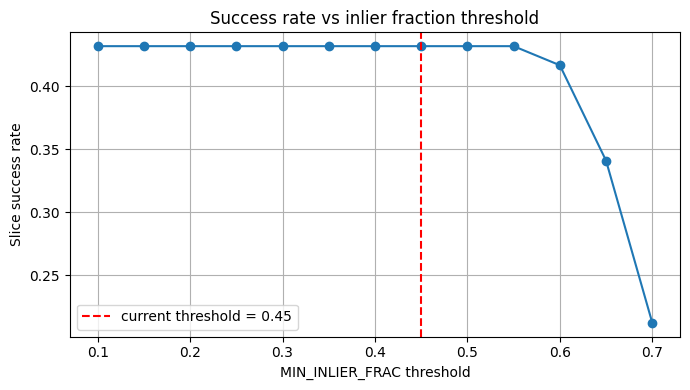

Largest drop at threshold 0.65 → 0.70
Suggested threshold: 0.70


In [99]:
import matplotlib.pyplot as plt

# --- Threshold sweep: success rate vs MIN_INLIER_FRAC ---
thresholds   = np.arange(0.10, 0.75, 0.05)
success_rates = []

for thresh in thresholds:
    count = sum(1 for r in inlier_ratios if r >= thresh)
    success_rates.append(count / n_total)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, success_rates, marker='o')
ax.axvline(MIN_INLIER_FRAC, color='red', linestyle='--', label=f'current threshold = {MIN_INLIER_FRAC}')
ax.set_xlabel("MIN_INLIER_FRAC threshold")
ax.set_ylabel("Slice success rate")
ax.set_title("Success rate vs inlier fraction threshold")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# Elbow: largest drop between adjacent thresholds
drops = np.diff(success_rates)
elbow_idx = np.argmin(drops)
print(f"Largest drop at threshold {thresholds[elbow_idx]:.2f} → {thresholds[elbow_idx+1]:.2f}")
print(f"Suggested threshold: {thresholds[elbow_idx+1]:.2f}")

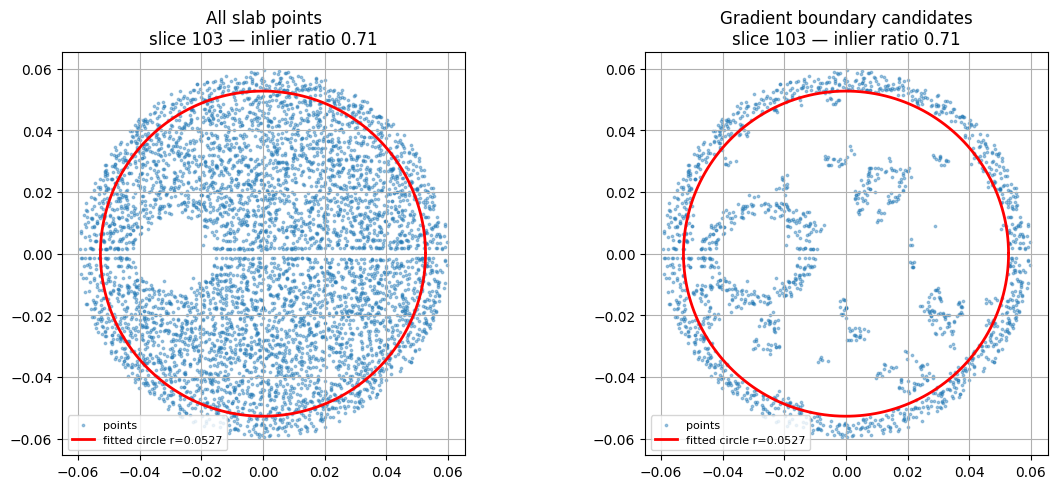

In [100]:
import matplotlib.pyplot as plt

# Visualise a representative slice: show all points, gradient candidates, and fitted circle
SLICE_IDX = len(fits) // 2  # middle of the successful fits

f   = fits[SLICE_IDX]
i   = f["i"]
c   = centers_smooth[i]
n   = tangents[i]
e1, e2 = get_plane_basis(n)

slab  = SLAB_HALF_THICK
idxs  = hole_tree.query_ball_point(c, r=BALL_R)
local = hole_pts[idxs]
local = local[np.abs((local - c) @ n) < slab]
rel2  = local - c
pts2d = np.column_stack([rel2 @ e1, rel2 @ e2])

grad_mask  = gradient_boundary_pts(pts2d, GRAD_GRID_RES, GRAD_THRESH_PCT)
candidates = pts2d[grad_mask]

cx_fit, cy_fit, r_fit = 0.0, 0.0, f["r"]
t = np.linspace(0, 2*np.pi, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pts, title in [
    (axes[0], pts2d,    "All slab points"),
    (axes[1], candidates, "Gradient boundary candidates"),
]:
    ax.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.4, label="points")
    ax.plot(cx_fit + r_fit*np.cos(t), cy_fit + r_fit*np.sin(t),
            'r-', linewidth=2, label=f"fitted circle r={r_fit:.4f}")
    ax.set_aspect('equal')
    ax.set_title(f"{title}\nslice {i} — inlier ratio {inlier_ratios[SLICE_IDX]:.2f}")
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.show()